In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neural_network import MLPClassifier

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# --- 1. Load Data ---

# Logic to handle local file or download if missing
file_path = 'bank-additional/bank-additional-full.csv'
zip_name = 'bank-additional.zip'
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"

if os.path.exists(file_path):
    print(f"Found ID dataset at {file_path}. Loading...")
    df = pd.read_csv(file_path, sep=';')
elif os.path.exists('bank-additional-full.csv'):
    print("Found dataset in current directory. Loading...")
    df = pd.read_csv('bank-additional-full.csv', sep=';')
else:
    print(f"Dataset not found locally. Downloading from {url}...")
    import urllib.request
    import zipfile
    
    # Download
    try:
        urllib.request.urlretrieve(url, zip_name)
        print("Download complete. Extracting...")
        with zipfile.ZipFile(zip_name, 'r') as zip_ref:
            zip_ref.extractall(".")
        print("Extraction complete.")
        df = pd.read_csv(file_path, sep=';')
    except Exception as e:
        print(f"Error downloading/extracting data: {e}")
        # Fallback to direct read if possible (unlikely if download failed)
        raise e

print("Data loaded successfully.")
print(f"Shape: {df.shape}")
display(df.head())

Dataset not found locally. Downloading from https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip...
Download complete. Extracting...
Extraction complete.
Data loaded successfully.
Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
# --- 2. Preprocessing ---

# Convert target to 0/1
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# Features & Target
X = df.drop('y', axis=1)
y = df['y']

# Identify column types
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

print(f"Numerical columns: {len(num_cols)}")
print(f"Categorical columns: {len(cat_cols)}")

# Pipelines
num_pipeline = Pipeline([('scaler', StandardScaler())])
cat_pipeline = Pipeline([('encoder', OneHotEncoder(handle_unknown='ignore'))])

preprocess = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Numerical columns: 10
Categorical columns: 10
Training set: (30891, 20)
Test set: (10297, 20)


Training Naive Bayes...

🔥 NAIVE BAYES RESULTS 🔥
Accuracy: 0.8144119646498981
              precision    recall  f1-score   support

           0       0.95      0.83      0.89      9144
           1       0.33      0.66      0.44      1153

    accuracy                           0.81     10297
   macro avg       0.64      0.75      0.67     10297
weighted avg       0.88      0.81      0.84     10297



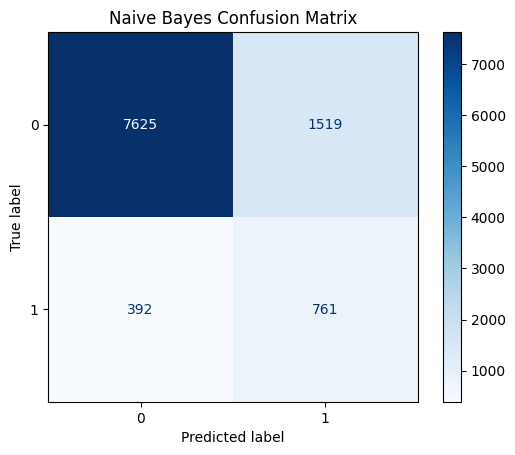

In [ ]:
# --- 3. Model: Naive Bayes ---

print("Training Naive Bayes...")
nb_model = Pipeline([
    ('prep', preprocess),
    ('clf', GaussianNB())
])
nb_model.fit(X_train, y_train)
pred_nb = nb_model.predict(X_test)

print("\n NAIVE BAYES RESULTS ")
print("Accuracy:", accuracy_score(y_test, pred_nb))
print(classification_report(y_test, pred_nb))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, pred_nb, cmap='Blues')
plt.title("Naive Bayes Confusion Matrix")
plt.show()

Training Decision Tree...

🌲 DECISION TREE RESULTS 🌲
Accuracy: 0.886180440905118
              precision    recall  f1-score   support

           0       0.94      0.93      0.94      9144
           1       0.49      0.52      0.50      1153

    accuracy                           0.89     10297
   macro avg       0.72      0.72      0.72     10297
weighted avg       0.89      0.89      0.89     10297



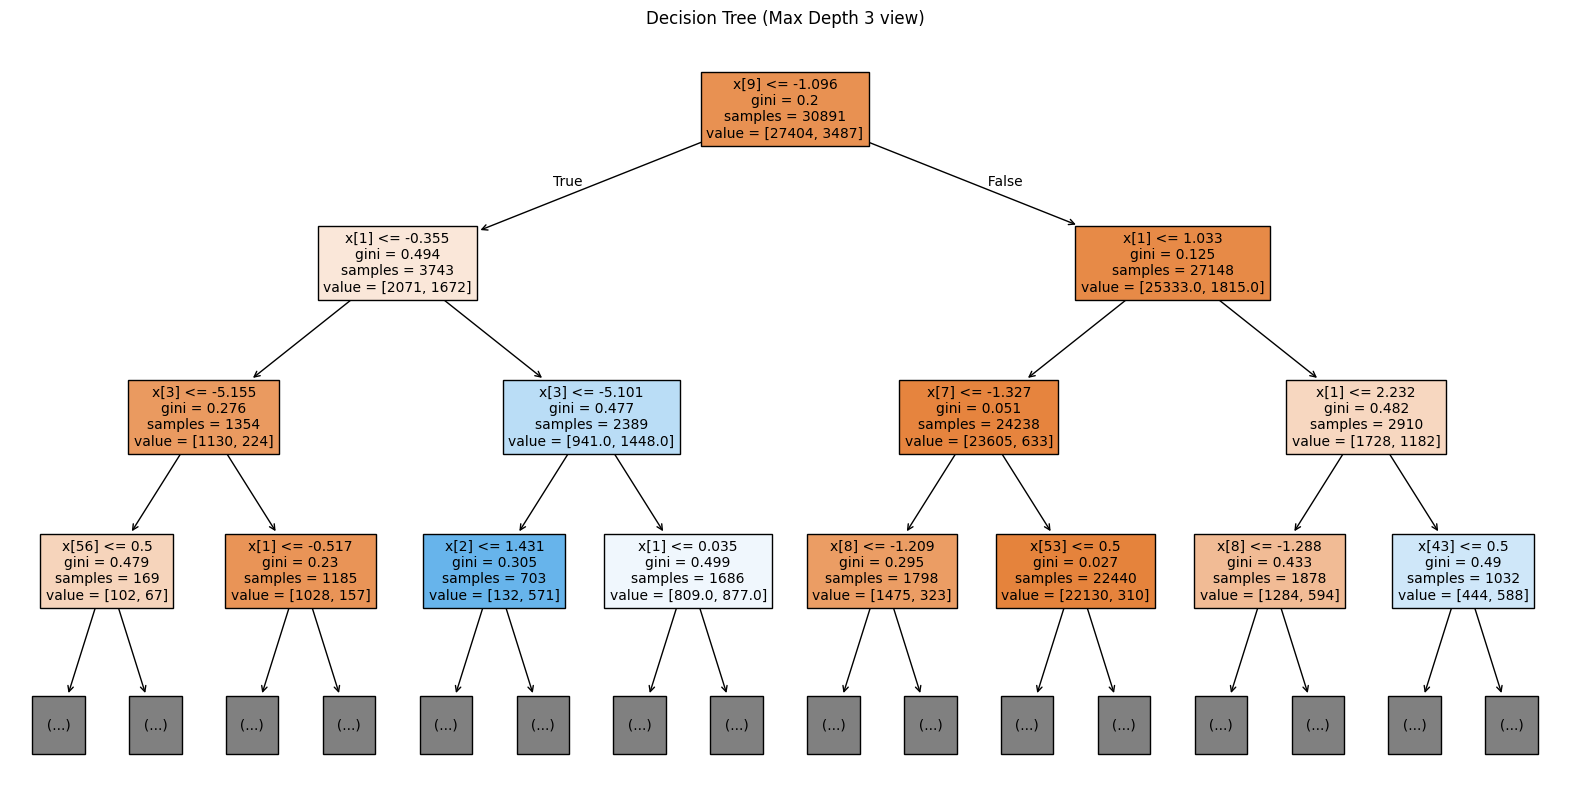

In [ ]:
# --- 4. Model: Decision Tree ---

print("Training Decision Tree...")
dt_model = Pipeline([
    ('prep', preprocess),
    ('clf', DecisionTreeClassifier(random_state=42))
])
dt_model.fit(X_train, y_train)
pred_dt = dt_model.predict(X_test)

print("\n DECISION TREE RESULTS ")
print("Accuracy:", accuracy_score(y_test, pred_dt))
print(classification_report(y_test, pred_dt))

# Visualizing the tree (limited depth for readability)
plt.figure(figsize=(20,10))
plot_tree(dt_model.named_steps['clf'], max_depth=3, filled=True, fontsize=10)
plt.title("Decision Tree (Max Depth 3 view)")
plt.show()

In [ ]:
# --- 5. Model: Neural Network (MLP) ---

print("Training MLP Classifier (this may take a few seconds)...")
mlp_model = Pipeline([
    ('prep', preprocess),
    ('clf', MLPClassifier(
        hidden_layer_sizes=(100,),
        activation='relu',
        solver='adam',
        max_iter=300,
        random_state=42
    ))
])
mlp_model.fit(X_train, y_train)
pred_mlp = mlp_model.predict(X_test)

print("\n NEURAL NETWORK (MLP) RESULTS ")
print("Accuracy:", accuracy_score(y_test, pred_mlp))
print(classification_report(y_test, pred_mlp))

Training MLP Classifier (this may take a few seconds)...


            Model  Accuracy
0     Naive Bayes  0.814412
1   Decision Tree  0.886180
2  MLP Classifier  0.898514


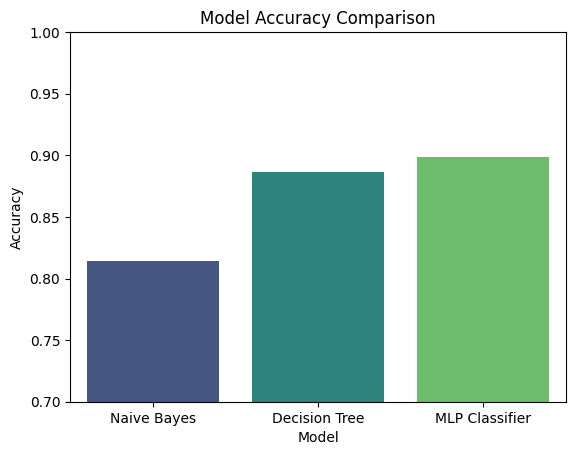

In [ ]:
# --- 6. Comparison ---

results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Decision Tree', 'MLP Classifier'],
    'Accuracy': [
        accuracy_score(y_test, pred_nb),
        accuracy_score(y_test, pred_dt),
        accuracy_score(y_test, pred_mlp)
    ]
})

print(results)
sns.barplot(x='Model', y='Accuracy', data=results, palette='viridis')
plt.title("Model Accuracy Comparison")
plt.ylim(0.7, 1.0)
plt.show()